In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import math

plt.rcParams["figure.figsize"]=(12,5)

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("stock.csv")  # ubah sesuai nama file

df.head()

Saving stock.csv to stock (1).csv


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       184 non-null    object 
 1   Open       184 non-null    float64
 2   High       184 non-null    float64
 3   Low        184 non-null    float64
 4   Close      184 non-null    float64
 5   Adj Close  184 non-null    float64
 6   Volume     184 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 10.2+ KB
None
             Open        High         Low       Close   Adj Close  \
count  184.000000  184.000000  184.000000  184.000000  184.000000   
mean   127.040245  129.918098  124.340381  127.352663  123.838032   
std     24.314449   24.577906   24.176736   24.356534   25.655569   
min     92.389999   93.769997   89.470001   90.519997   87.796822   
25%    108.882499  112.362499  106.152502  109.204998  105.301765   
50%    118.895000  120.865002  116.870003  119.190002 

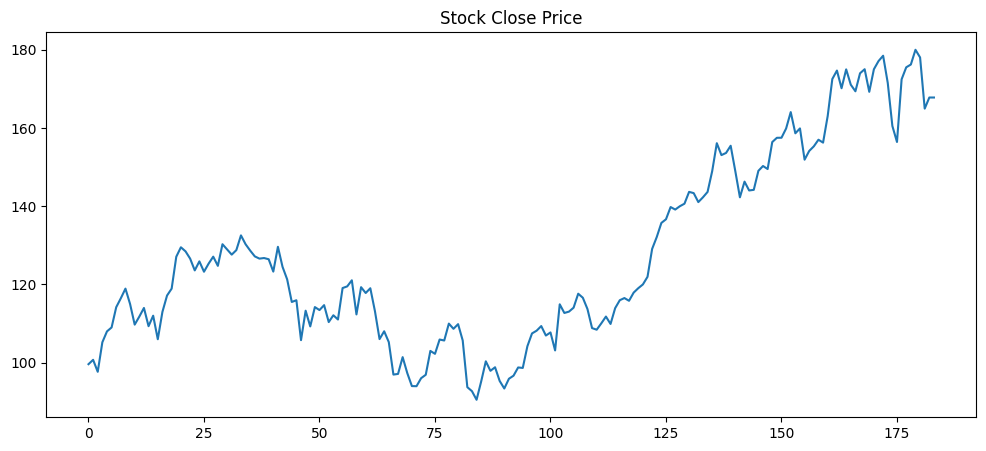

In [ ]:
print(df.info())
print(df.describe())

plt.plot(df['Close'])
plt.title("Stock Close Price")
plt.show()

In [ ]:
data = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

In [ ]:
X = []
y = []

window_size = 5

for i in range(len(data_scaled)-window_size):
    X.append(data_scaled[i:i+window_size, 0])
    y.append(data_scaled[i+window_size, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [ ]:
model = Sequential()

model.add(Dense(10, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(5, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='loss', patience=10)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - loss: 0.0087
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0059
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0056
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0055 
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0053
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0053 
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0053 
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0052 
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0051 
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0051 
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0050 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0050 
Epoch 13/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 
Epoch 14/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0048 
Epoch 15/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 
Epoch 16/100
9/9 

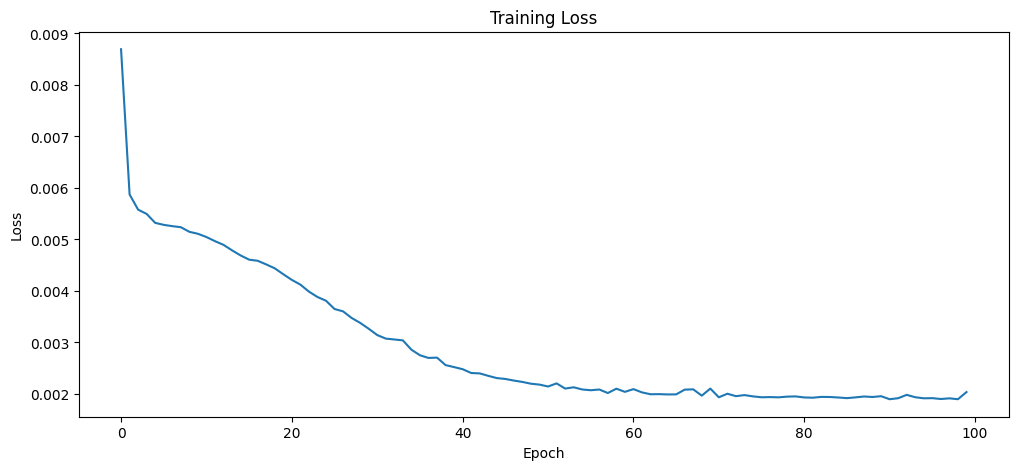

In [ ]:
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


In [ ]:
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_inv = scaler.inverse_transform(y_pred)

In [ ]:
rmse = math.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 5.778086229477555
MAE: 4.580911008517797
MAPE: 2.7436682232280556


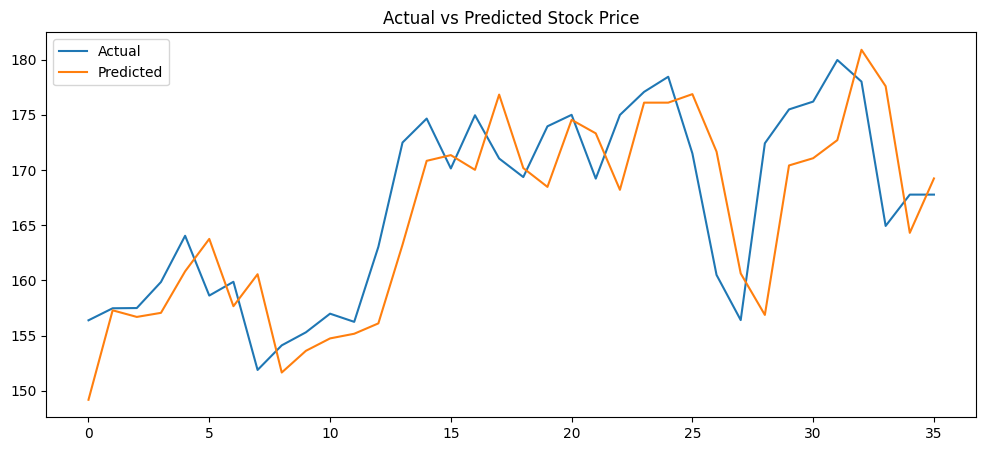

In [ ]:
plt.plot(y_test_inv, label="Actual")
plt.plot(y_pred_inv, label="Predicted")
plt.title("Actual vs Predicted Stock Price")
plt.legend()
plt.show()

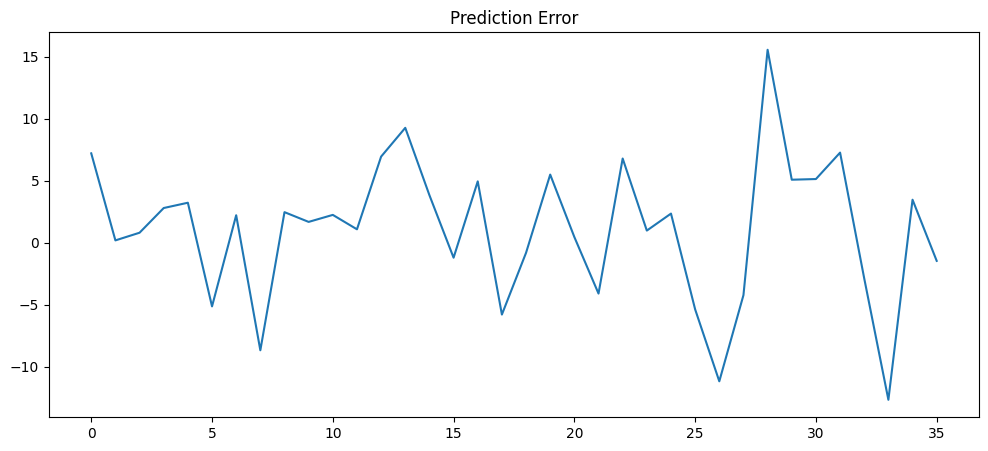

In [ ]:
error = y_test_inv - y_pred_inv

plt.plot(error)
plt.title("Prediction Error")
plt.show()

In [ ]:
last_data = data_scaled[-5:].reshape(1,5)

next_price_scaled = model.predict(last_data)
next_price = scaler.inverse_transform(next_price_scaled)

print("Next Day Price:", next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Next Day Price: 166.2846


In [ ]:
model.save("stock_ann_model.h5")
print("Model saved!")

Model saved!


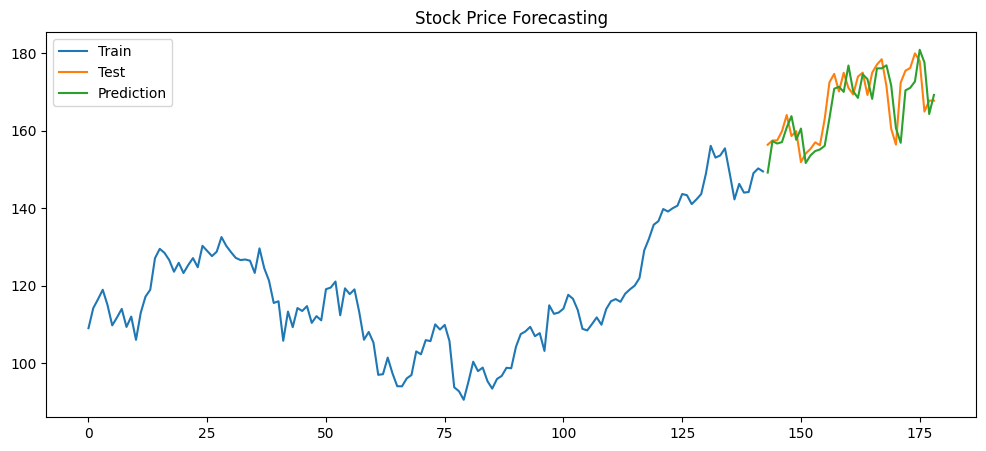

In [ ]:
train_size = len(X_train)

plt.plot(np.arange(train_size), scaler.inverse_transform(y_train.reshape(-1,1)), label="Train")
plt.plot(np.arange(train_size, train_size + len(y_test)), y_test_inv, label="Test")
plt.plot(np.arange(train_size, train_size + len(y_test)), y_pred_inv, label="Prediction")

plt.title("Stock Price Forecasting")
plt.legend()
plt.show()

In [ ]:
def directional_accuracy(y_true, y_pred):
    correct = 0
    for i in range(1, len(y_true)):
        if (y_true[i] > y_true[i-1] and y_pred[i] > y_pred[i-1]) or \
           (y_true[i] < y_true[i-1] and y_pred[i] < y_pred[i-1]):
            correct += 1
    return (correct / (len(y_true)-1)) * 100

print("Directional Accuracy:", directional_accuracy(y_test_inv, y_pred_inv))

Directional Accuracy: 51.42857142857142


In [ ]:
print("Max Price:", np.max(data))
print("Min Price:", np.min(data))
print("Mean Price:", np.mean(data))
print("Std Dev:", np.std(data))

Max Price: 179.979996
Min Price: 90.519997
Mean Price: 127.35266294565217
Std Dev: 24.290257770958277


In [ ]:
print("===== STOCK PRICE ANN RESULT =====")
print("RMSE :", rmse)
print("MAE  :", mae)
print("MAPE :", mape)
print("Directional Accuracy :", directional_accuracy(y_test_inv, y_pred_inv))
print("==================================")

===== STOCK PRICE ANN RESULT =====
RMSE : 5.778086229477555
MAE  : 4.580911008517797
MAPE : 2.7436682232280556
Directional Accuracy : 51.42857142857142
